# 05 — Erros, acertos parciais e divergências

Estudo dos casos problemáticos e das justificativas.

In [1]:
# Configuração comum dos estudos integrados
from pathlib import Path
import re
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22

ARTEFATOS = {
    'unificado': 'result_unificado_final.xlsx',
    'ferramenta': 'result_ferramenta_final.xlsx',
    'chats': 'result_chats_final.xlsx',
}

PASTAS_PROVAVEIS = [
    Path('../artefatos'),
    Path('../../artefatos'),
    Path('artefatos'),
    Path('../'),
    Path('.'),
    Path('/mnt/data'),
]

def encontra_arquivo(nome):
    for pasta in PASTAS_PROVAVEIS:
        caminho = pasta / nome
        if caminho.exists():
            return caminho.resolve()
    raise FileNotFoundError(
        f'Arquivo não encontrado: {nome}. Coloque os artefatos em ../artefatos/, artefatos/ ou na mesma pasta do notebook.'
    )

NOMES_MODELOS = {
    'claude-haiku-4-5': 'Claude Haiku',
    'claude-opus-4-7': 'Claude Opus',
    'claude-sonnet-4-6': 'Claude Sonnet',
    'deepseek-v4-flash': 'DeepSeek Flash',
    'deepseek-v4-pro': 'DeepSeek Pro',
    'gpt-4o-mini': 'GPT 4o mini',
    'gpt-5.4': 'GPT 5.4',
    'gpt-5.4-mini': 'GPT 5.4 mini',
    'gpt-5.5': 'GPT 5.5',
    'std_chatgpt': 'ChatGPT comercial',
    'std_claude': 'Claude comercial',
}

def provedor(modelo):
    m = str(modelo).lower()
    if 'claude' in m:
        return 'Anthropic'
    if 'gpt' in m or 'chatgpt' in m:
        return 'OpenAI'
    if 'deepseek' in m:
        return 'DeepSeek'
    return 'Outro'

def prepara(df, origem_padrao=None):
    """Cria campos de leitura do TCC em memória. Não salva nenhuma base intermediária."""
    df = df.copy()
    if 'origem_resultado' not in df.columns:
        df['origem_resultado'] = origem_padrao or 'nao_informada'
    for col in [
        'avaliacao_final', 'concisao_score', 'avaliacao_gpt', 'avaliacao_opus',
        'avaliacao_humana', 'resposta_tokens_tiktoken', 'input_tokens', 'output_tokens',
        'custo_estimado_usd', 'n_invocacoes', 'latencia_s'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('nao pertinente', np.nan), errors='coerce')
    if 'convergencia' in df.columns:
        df['convergencia'] = df['convergencia'].astype(bool)
    else:
        df['convergencia'] = np.nan
    df['acerto'] = df['avaliacao_final']
    df['resposta_direta'] = df['concisao_score']
    df['discordancia_avaliadores'] = ~df['convergencia']
    df['origem_legivel'] = df['origem_resultado'].map({
        'ferramenta': 'Ferramenta',
        'chat_comercial': 'Chat comercial'
    }).fillna(df['origem_resultado'])
    df['modelo_legivel'] = df['modelo'].map(NOMES_MODELOS).fillna(df['modelo'])
    df['provedor'] = df['modelo'].map(provedor)
    df['status_acerto'] = pd.cut(
        df['acerto'], bins=[-0.01, 0.01, 0.99, 1.01],
        labels=['Incorreta', 'Parcial', 'Correta']
    )
    df['acerto_total'] = (df['acerto'] == 1).astype(int)
    df['erro_total'] = (df['acerto'] == 0).astype(int)
    df['parcial'] = (df['acerto'] == 0.5).astype(int)
    df['nao_totalmente_correta'] = (df['acerto'] < 1).astype(int)
    return df

def ler_artefatos():
    caminhos = {k: encontra_arquivo(v) for k, v in ARTEFATOS.items()}
    df_unificado = prepara(pd.read_excel(caminhos['unificado']))
    df_ferramenta = prepara(pd.read_excel(caminhos['ferramenta']), 'ferramenta')
    df_chats = prepara(pd.read_excel(caminhos['chats']), 'chat_comercial')
    return caminhos, df_unificado, df_ferramenta, df_chats

caminhos, df, df_ferramenta, df_chats = ler_artefatos()
print('Artefatos lidos:')
for nome, caminho in caminhos.items():
    print(f'- {nome}: {caminho}')
print(f'Base unificada: {df.shape[0]} linhas x {df.shape[1]} colunas')

# Ordem padrão dos modelos: maior acerto médio primeiro.
ORDEM_MODELOS = (
    df.groupby('modelo_legivel')['acerto']
      .mean()
      .sort_values(ascending=False)
      .index
      .tolist()
)

def pct(x):
    if pd.isna(x):
        return ''
    return f'{100*x:.1f}%'

def dinheiro(x):
    if pd.isna(x):
        return ''
    return f'US$ {x:.5f}'

def resumo_metricas(data, grupo):
    g = data.groupby(grupo, observed=True)
    out = g.agg(
        n=('acerto', 'size'),
        acerto_medio=('acerto', 'mean'),
        taxa_correta=('acerto_total', 'mean'),
        taxa_parcial=('parcial', 'mean'),
        taxa_incorreta=('erro_total', 'mean'),
        resposta_direta=('resposta_direta', 'mean'),
        discordancia=('discordancia_avaliadores', 'mean'),
        tokens_resposta=('resposta_tokens_tiktoken', 'mean'),
    ).reset_index()
    return out

def ordena_por_modelo(series_or_df, col=None):
    if isinstance(series_or_df, pd.Series):
        return series_or_df.reindex([m for m in ORDEM_MODELOS if m in series_or_df.index])
    return series_or_df.set_index(col).reindex([m for m in ORDEM_MODELOS if m in series_or_df[col].values]).reset_index()

def barh_series(s, titulo, xlabel='', percentual=False, figsize=(8, 5), limite=None):
    s = s.dropna().copy()
    if limite is not None:
        s = s.sort_values(ascending=False).head(limite)
    else:
        s = s.sort_values(ascending=True)
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()

def bar_series(s, titulo, xlabel='', ylabel='', percentual=False, figsize=(8, 4), rot=0):
    s = s.dropna().copy()
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rot)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    plt.show()

def stacked_percent(data, index_col, column_col, titulo, ordem_colunas=None, figsize=(9, 6)):
    tab = pd.crosstab(data[index_col], data[column_col], normalize='index')
    if ordem_colunas:
        tab = tab.reindex(columns=[c for c in ordem_colunas if c in tab.columns])
    tab = tab.loc[tab.sum(axis=1).sort_values().index]
    ax = (tab * 100).plot(kind='barh', stacked=True, figsize=figsize)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel('% das respostas')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()
    return tab

def heatmap_tabela(pivot, titulo, formato='.1f', percentual=True, figsize=(9, 5)):
    dados = pivot.copy()
    valores = dados.values * 100 if percentual else dados.values
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(valores, aspect='auto')
    ax.set_title(titulo, loc='left')
    ax.set_xticks(np.arange(dados.shape[1]))
    ax.set_xticklabels(dados.columns.astype(str), rotation=35, ha='right')
    ax.set_yticks(np.arange(dados.shape[0]))
    ax.set_yticklabels(dados.index.astype(str))
    # Só anota quando a matriz é pequena o suficiente para não virar poluição visual.
    if dados.shape[0] * dados.shape[1] <= 80:
        for i in range(dados.shape[0]):
            for j in range(dados.shape[1]):
                val = valores[i, j]
                if not np.isnan(val):
                    texto = f'{val:{formato}}' + ('%' if percentual else '')
                    ax.text(j, i, texto, ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    plt.tight_layout()
    plt.show()

def boxplot_por_grupo(data, valor, grupo, titulo, ylabel='', figsize=(9, 5), ordem=None):
    base = data[[valor, grupo]].dropna()
    if ordem is None:
        ordem = base.groupby(grupo)[valor].median().sort_values().index.tolist()
    grupos = [base.loc[base[grupo] == g, valor].values for g in ordem if g in base[grupo].unique()]
    labels = [g for g in ordem if g in base[grupo].unique()]
    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(grupos, labels=labels, vert=False, showfliers=False)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(ylabel or valor)
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

def tabela_formatada(data, percent_cols=None, money_cols=None, round_cols=None, n=20):
    out = data.copy().head(n)
    percent_cols = percent_cols or []
    money_cols = money_cols or []
    round_cols = round_cols or []
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(pct)
    for c in money_cols:
        if c in out.columns:
            out[c] = out[c].map(dinheiro)
    for c in round_cols:
        if c in out.columns:
            out[c] = out[c].round(3)
    display(out)

def texto_curto(s, n=180):
    if pd.isna(s):
        return ''
    s = re.sub(r'\s+', ' ', str(s)).strip()
    return s if len(s) <= n else s[:n-1] + '…'

Artefatos lidos:
- unificado: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_unificado_final.xlsx
- ferramenta: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_ferramenta_final.xlsx
- chats: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_chats_final.xlsx
Base unificada: 1650 linhas x 34 colunas


## Pergunta do estudo
Onde estão os erros, os acertos parciais e as discordâncias entre avaliadores?

In [2]:
erros = df[df['acerto'] == 0].copy()
parciais = df[df['acerto'] == 0.5].copy()
nao_total = df[df['acerto'] < 1].copy()
display(Markdown(f'### Incorretas: {len(erros)} | Parciais: {len(parciais)} | Não totalmente corretas: {len(nao_total)}'))

### Incorretas: 20 | Parciais: 133 | Não totalmente corretas: 153

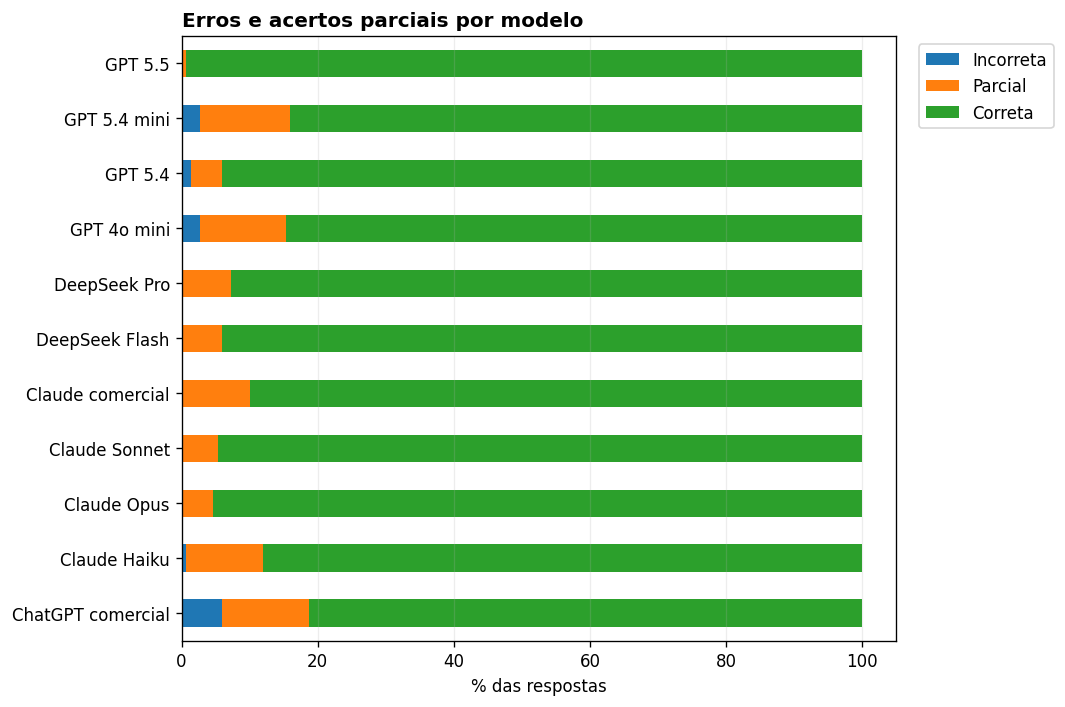

status_acerto,Incorreta,Parcial,Correta
modelo_legivel,,,
ChatGPT comercial,0.060000,0.126667,0.813333
Claude Haiku,0.006667,0.113333,0.880000
Claude Opus,0.000000,0.046667,0.953333
Claude Sonnet,0.000000,0.053333,0.946667
Claude comercial,0.000000,0.100000,0.900000
DeepSeek Flash,0.000000,0.060000,0.940000
DeepSeek Pro,0.000000,0.073333,0.926667
GPT 4o mini,0.026667,0.126667,0.846667
GPT 5.4,0.013333,0.046667,0.940000


In [3]:
status_modelo = pd.crosstab(df['modelo_legivel'], df['status_acerto'], normalize='index')
stacked_percent(df, 'modelo_legivel', 'status_acerto', 'Erros e acertos parciais por modelo', ordem_colunas=['Incorreta','Parcial','Correta'], figsize=(9, 6))

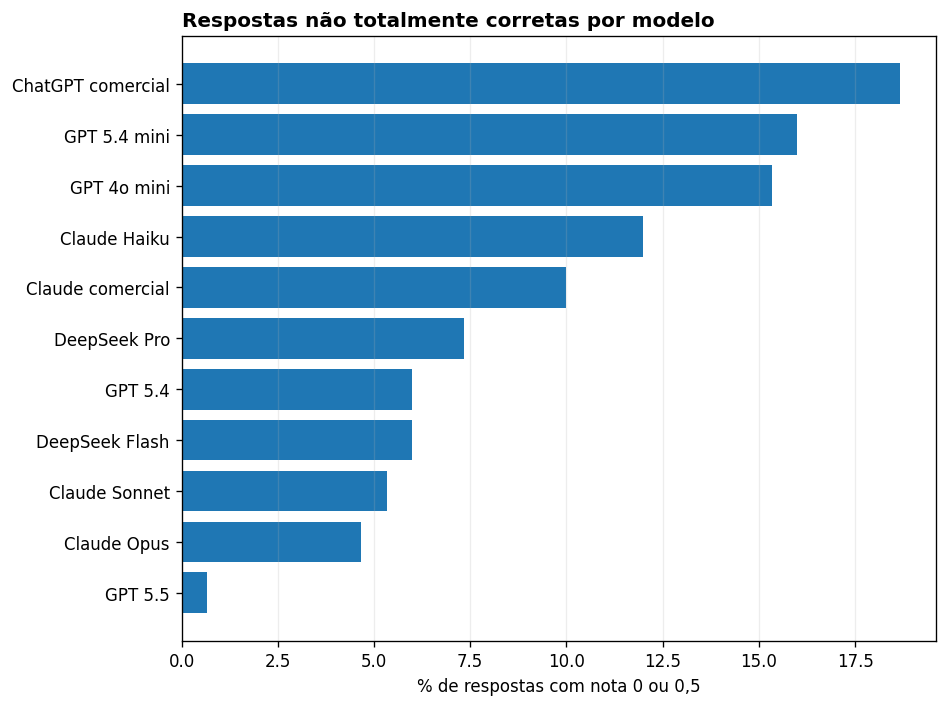

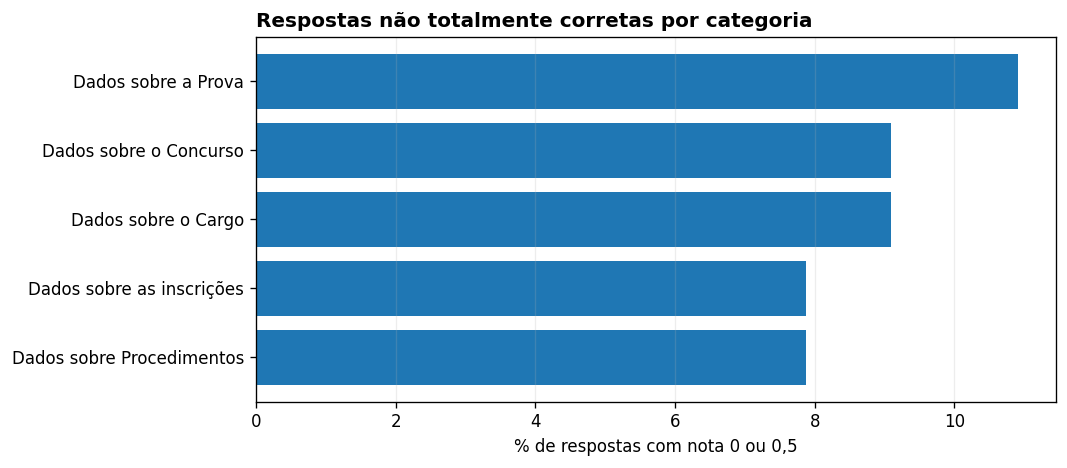

In [4]:
barh_series(df.groupby('modelo_legivel')['nao_totalmente_correta'].mean().sort_values(), 'Respostas não totalmente corretas por modelo', '% de respostas com nota 0 ou 0,5', percentual=True, figsize=(8, 6))
barh_series(df.groupby('categoria')['nao_totalmente_correta'].mean().sort_values(), 'Respostas não totalmente corretas por categoria', '% de respostas com nota 0 ou 0,5', percentual=True, figsize=(9, 4))

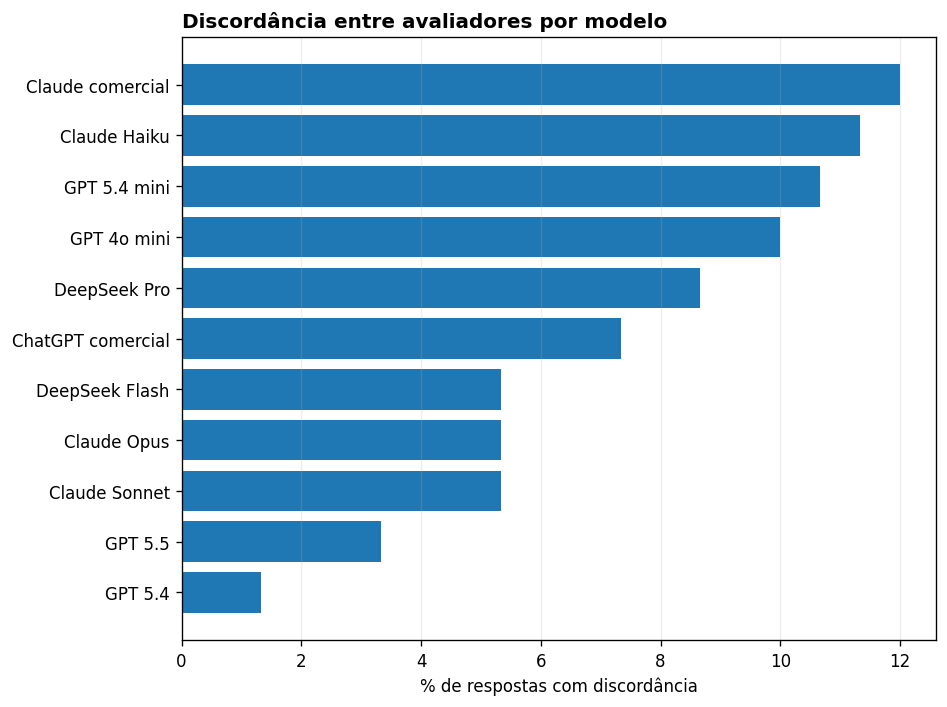

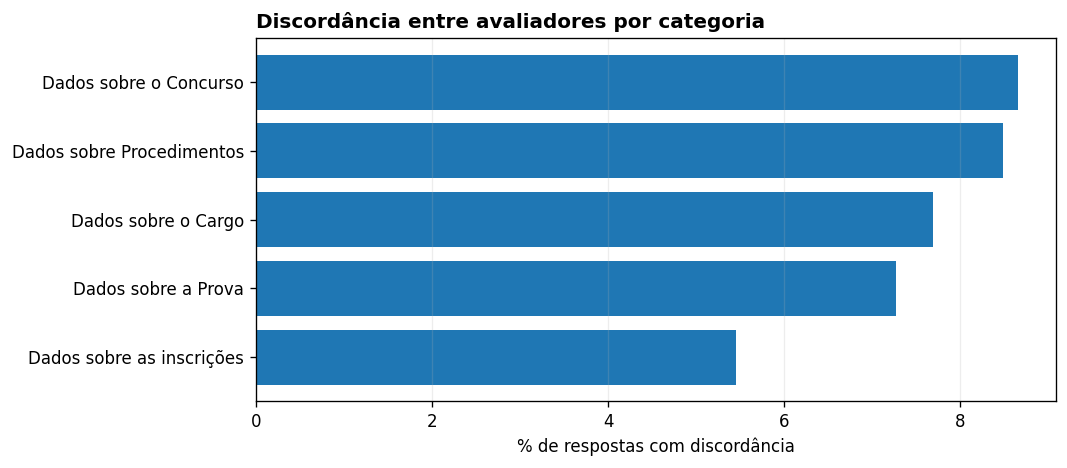

In [5]:
div_modelo = df.groupby('modelo_legivel')['discordancia_avaliadores'].mean().sort_values()
div_cat = df.groupby('categoria')['discordancia_avaliadores'].mean().sort_values()
barh_series(div_modelo, 'Discordância entre avaliadores por modelo', '% de respostas com discordância', percentual=True, figsize=(8, 6))
barh_series(div_cat, 'Discordância entre avaliadores por categoria', '% de respostas com discordância', percentual=True, figsize=(9, 4))

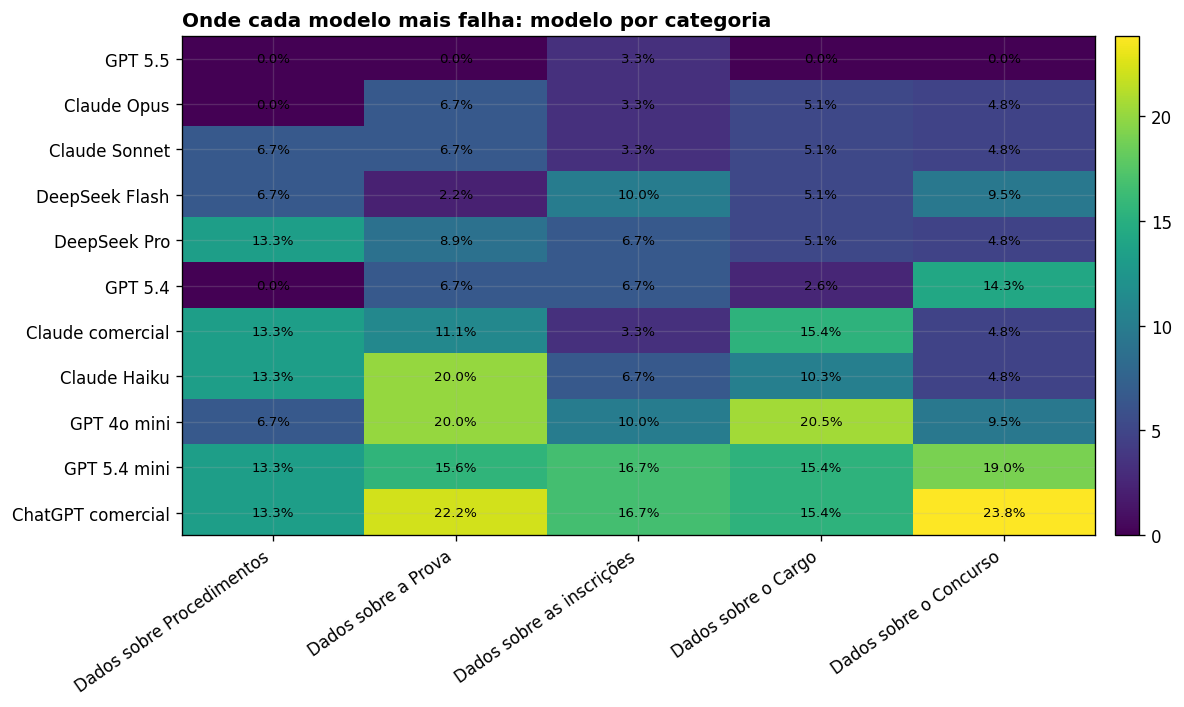

In [6]:
pivot = df.pivot_table(index='modelo_legivel', columns='categoria', values='nao_totalmente_correta', aggfunc='mean').reindex(ORDEM_MODELOS)
heatmap_tabela(pivot, 'Onde cada modelo mais falha: modelo por categoria', formato='.1f', percentual=True, figsize=(10, 6))

In [7]:
exemplos = nao_total.copy()
exemplos['pergunta_curta'] = exemplos['pergunta'].map(lambda x: texto_curto(x, 140))
exemplos['resposta_curta'] = exemplos['resposta'].map(lambda x: texto_curto(x, 200))
exemplos['justificativa_curta'] = exemplos['justificativa_gpt'].fillna(exemplos['justificativa_opus']).map(lambda x: texto_curto(x, 220))
cols = ['origem_legivel','edital','modelo_legivel','categoria','acerto','resposta_direta','pergunta_curta','resposta_curta','justificativa_curta']
display(Markdown('### Exemplos de respostas não totalmente corretas'))
display(exemplos[cols].sort_values(['acerto','origem_legivel','modelo_legivel']).head(25))

### Exemplos de respostas não totalmente corretas

,origem_legivel,edital,modelo_legivel,categoria,acerto,resposta_direta,pergunta_curta,resposta_curta,justificativa_curta
1370,Chat comercial,bndes,ChatGPT comercial,Dados sobre o Cargo,0.0,1,Qual percentual ou regra de reserva de vagas PcD existe no concurso BNDES?,O edital do concurso do Banco Nacional de Desenvolvimento Econômico e Social prevê a reserva de 10% das vagas para p...,"Errado. O item 3.1.2 (p. 4) reserva 15% das vagas às pessoas com deficiência, não 10%. O item 5.4.2 (p. 9) ainda pre..."
1384,Chat comercial,bndes,ChatGPT comercial,Dados sobre a Prova,0.0,1,Quantas questões ou itens de conhecimentos básicos existem no concurso BNDES?,"No concurso do Banco Nacional de Desenvolvimento Econômico e Social, a parte de Conhecimentos Básicos das provas obj...","Errado. O item 8.1.2 (p. 14) estabelece 35 questões de Conhecimentos Básicos: 20 de Conhecimentos Transversais, 10 d..."
1385,Chat comercial,bndes,ChatGPT comercial,Dados sobre a Prova,0.0,1,Quantas questões ou itens de conhecimentos específicos existem no concurso BNDES?,"No concurso do Banco Nacional de Desenvolvimento Econômico e Social, a parte de Conhecimentos Específicos das provas...","Errado. O item 8.1.2 (p. 14) estabelece 35 questões de Conhecimentos Específicos, não 50."
1391,Chat comercial,bndes,ChatGPT comercial,Dados sobre a Prova,0.0,1,Quantos pontos vale a prova discursiva do concurso BNDES?,A prova discursiva do concurso do Banco Nacional de Desenvolvimento Econômico e Social vale 100 pontos no total. 202...,"Errado. O item 8.1.5 (p. 14) afirma que a prova discursiva totaliza 50 pontos (5 questões de 10 pontos), não 100 pon..."
1392,Chat comercial,bndes,ChatGPT comercial,Dados sobre a Prova,0.0,1,Qual é a nota mínima da prova discursiva no concurso BNDES?,"Para ser aprovado na prova discursiva do concurso do Banco Nacional de Desenvolvimento Econômico e Social, o candida...",Errado. O item 8.1.5.1 (p. 14) elimina quem obtiver aproveitamento inferior a 60% do total da prova discursiva. Como...
1394,Chat comercial,bndes,ChatGPT comercial,Dados sobre a Prova,0.0,1,Como é calculada a nota final do concurso BNDES para Ciência de Dados?,A nota final do candidato de Ciência de Dados no concurso do Banco Nacional de Desenvolvimento Econômico e Social é ...,"Meio certo. O item 8.1.7 (p. 15) determina classificação pelo somatório dos pontos das duas fases. Porém, os itens 8..."
1396,Chat comercial,bndes,ChatGPT comercial,Dados sobre Procedimentos,0.0,1,Qual é a duração ou organização dos turnos de prova do concurso BNDES?,"No concurso do Banco Nacional de Desenvolvimento Econômico e Social, as provas foram organizadas em dois turnos no m...","Meio certo. O item 9.1 (p. 15) prevê dois turnos: provas objetivas pela manhã, com 4 horas, e prova discursiva à tar..."
1554,Chat comercial,petrobras,ChatGPT comercial,Dados sobre as inscrições,0.0,1,Qual é o prazo-limite de pagamento da inscrição do concurso PETROBRAS?,O prazo-limite para pagamento da taxa de inscrição do concurso PETROBRAS foi 7 de janeiro de 2022.,"Errado. O Anexo IV (Cronograma), p. 47, informa como data limite para pagamento 28/1/2022, não 7/1/2022."
1562,Chat comercial,petrobras,ChatGPT comercial,Dados sobre o Concurso,0.0,1,Qual é o prazo de validade do concurso PETROBRAS?,"O prazo de validade do concurso PETROBRAS é de 18 meses, contados a partir da data de publicação da homologação do r...","Errado. O item 11.5, p. 19, estabelece validade de 12 meses a contar da publicação do edital de homologação dos resu..."
916,Ferramenta,petrobras,Claude Haiku,Dados sobre o Concurso,0.0,0,Existe possibilidade de impugnar o edital do concurso PETROBRAS?,"Sim, existe possibilidade de impugnar o edital, mas de forma específica e limitada. O edital prevê recursos em vária...","Errado. O edital não prevê impugnação do edital propriamente dita; ele trata de recursos contra etapas específicas, ..."


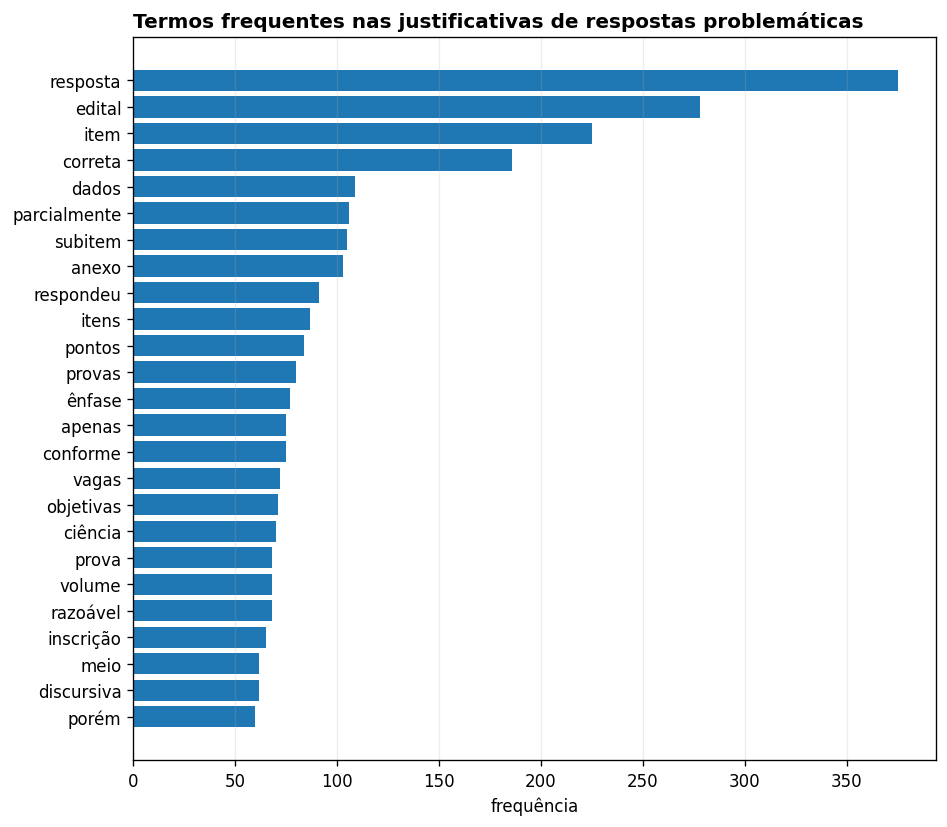

,termo,frequência
0,resposta,375
1,edital,278
2,item,225
3,correta,186
4,dados,109
5,parcialmente,106
6,subitem,105
7,anexo,103
8,respondeu,91
9,itens,87


In [8]:
# Termos frequentes nas justificativas de erro/parcial, sem depender de bibliotecas externas.
stop = set("a o os as um uma uns umas de do da dos das e em no na nos nas para por com sem sobre que se ao aos à às é foi são está esta este essa esse isso como mais menos muito pouco também entre quando onde qual quais sua seu suas seus não sim ou já há pela pelo pelas pelos".split())
texto = ' '.join(nao_total[['justificativa_gpt','justificativa_opus','justificativa_concisao']].fillna('').agg(' '.join, axis=1).tolist()).lower()
palavras = re.findall(r'[a-záéíóúãõâêôç]{4,}', texto)
freq = pd.Series([p for p in palavras if p not in stop]).value_counts().head(25)
barh_series(freq.sort_values(), 'Termos frequentes nas justificativas de respostas problemáticas', 'frequência', figsize=(8, 7))
display(freq.rename('frequência').reset_index().rename(columns={'index':'termo'}))